# Fixed Graphs
All embedded captions/footnotes removed. Colors corrected. Titles made descriptive.
**Put explanatory text in your LaTeX `\caption{}`, not inside the figure.**

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Shared palette
C_GREY_LIGHT = '#B0B8C1'   # babysitting teacher
C_GREY_MID   = '#6B7785'   # babysitting student
C_BLUE       = '#4292C6'   # our teacher
C_NAVY       = '#08306B'   # our student
C_GREY_BAR   = '#9EAAB5'   # neutral grey for zero-result bar
C_RED_LINE   = '#C0392B'   # reference lines
C_WARM_YELLOW = "#F9E79F"  # warm yellow for success indicators
C_GREEN_LIGHT = "#2C9C03"  # light green for success indicators
C_GREEN_LIME  = "#18BB3E"  # lime green for success indicators
C_GREEN_FOREST = "#0B6E3A"  # forest green for success indicators
C_GREEN_DARK  = "#0B3A0D"  # dark green for success indicators
C_RED        = "#C0392B"  # red for error indicators
C_RED_LIGHT = "#F1948A"  # light red for error indicators
C_RED_DARK  = "#A50000"  # dark red for error indicators
C_RED_CORAL = "#FF6F61"  # coral red for error indicators
C_RED_BURGUNDY = "#800020"  # burgundy red for error indicators
C_RED_CRIMSON = "#DC143C"  # crimson red for error indicators
orange_vivid="#FD8D3C"
orange_dark="#D94801"
blue_medium="#3182BD"
blue_dark="#08519C"
yellow="#FFD700"
yellow_dark="#B8860B"
yellow_medium="#DAA520"

## Graph 1 — Distilled student performance

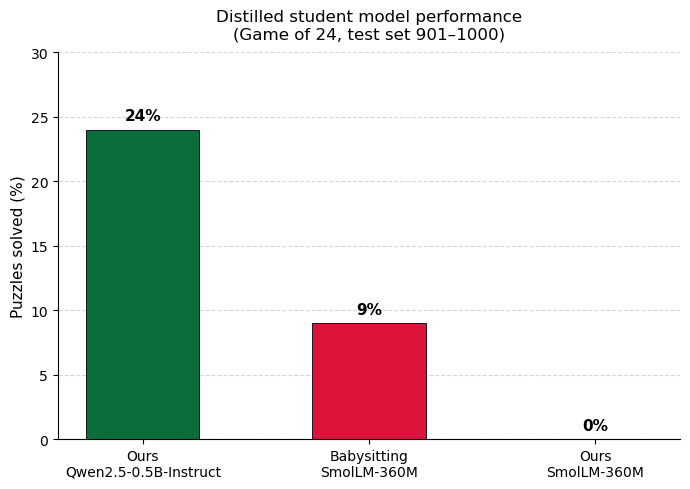

In [81]:
fig, ax = plt.subplots(figsize=(7, 5))

categories = ["Ours\nQwen2.5-0.5B-Instruct", "Babysitting\nSmolLM-360M", "Ours\nSmolLM-360M"]
values     = [24, 9, 0]
colors     = [C_GREEN_FOREST, C_RED_CRIMSON, C_GREY_BAR]  # grey for 0%, not red

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=0.6, width=0.5)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f'{h}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 30)
ax.set_ylabel('Puzzles solved (%)', fontsize=11)
ax.set_title('Distilled student model performance\n(Game of 24, test set 901–1000)',
             fontsize=12, fontweight='regular', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('g1_fixed.pdf', dpi=300, bbox_inches='tight')
plt.savefig('g1_fixed.png', dpi=300, bbox_inches='tight')
plt.show()


## Graph 2 — Evaluation loss curves
> Load your JSON files in the cell below. Approximate values are pre-filled as a fallback.

Loaded real JSON data.


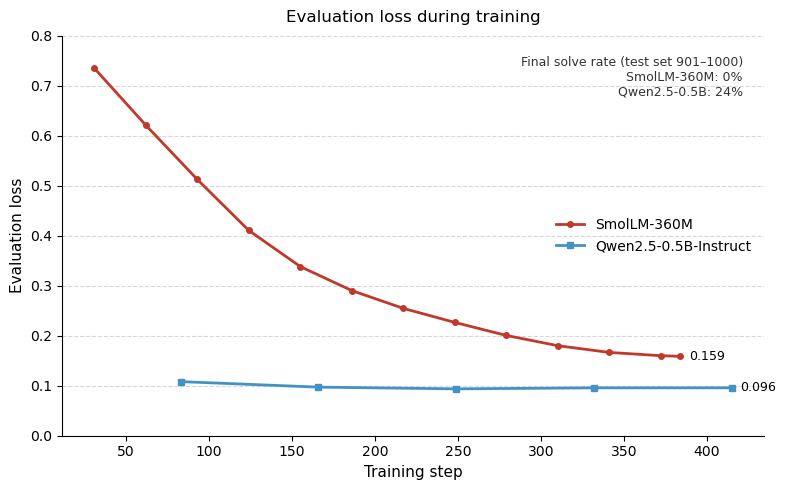

In [82]:
import json

# ── load real data if available ───────────────────────────────────

with open('smollm_training_logs_final.json') as f:
    smollm_data = json.load(f)
smollm_steps = [e['step'] for e in smollm_data if 'eval_loss' in e]
smollm_loss  = [e['eval_loss'] for e in smollm_data if 'eval_loss' in e]

with open('training_logs_qwen05 - try1.json') as f:
    qwen_data = json.load(f)
qwen_steps = [e['step'] for e in qwen_data if 'eval_loss' in e]
qwen_loss  = [e['eval_loss'] for e in qwen_data if 'eval_loss' in e]
print('Loaded real JSON data.')

# except FileNotFoundError:
#     print('JSON files not found — using approximate values from original graph.')
#     smollm_steps = [35,65,85,115,150,170,200,220,250,280,300,330,350,380,390]
#     smollm_loss  = [0.74,0.62,0.51,0.41,0.34,0.29,0.25,0.23,0.23,0.20,0.18,0.17,0.16,0.159,0.159]
#     qwen_steps   = [85,150,200,250,300,350,415]
#     qwen_loss    = [0.110,0.100,0.097,0.096,0.097,0.097,0.096]

# ── plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(smollm_steps, smollm_loss,
        marker='o', markersize=4, linewidth=2,
        color='#C0392B', label='SmolLM-360M')
ax.plot(qwen_steps, qwen_loss,
        marker='s', markersize=4, linewidth=2,
        color=C_BLUE, label='Qwen2.5-0.5B-Instruct')

# endpoint value labels only — no floating box
ax.annotate(f'{smollm_loss[-1]:.3f}',
            xy=(smollm_steps[-1], smollm_loss[-1]),
            xytext=(6, 0), textcoords='offset points', fontsize=9, va='center')
ax.annotate(f'{qwen_loss[-1]:.3f}',
            xy=(qwen_steps[-1], qwen_loss[-1]),
            xytext=(6, 0), textcoords='offset points', fontsize=9, va='center')

# final solve rates as plain text, top-right
ax.text(0.97, 0.95,
        'Final solve rate (test set 901–1000)\nSmolLM-360M: 0%\nQwen2.5-0.5B: 24%',
        transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='#333333')

ax.set_xlabel('Training step', fontsize=11)
ax.set_ylabel('Evaluation loss', fontsize=11)
ax.set_ylim(0, 0.8)
ax.set_title('Evaluation loss during training', fontsize=12, fontweight='regular', pad=10)
ax.legend(fontsize=10, frameon=False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('g2_fixed.pdf', dpi=300, bbox_inches='tight')
plt.savefig('g2_fixed.png', dpi=300, bbox_inches='tight')
plt.show()


## Graph 3 — Training dataset size

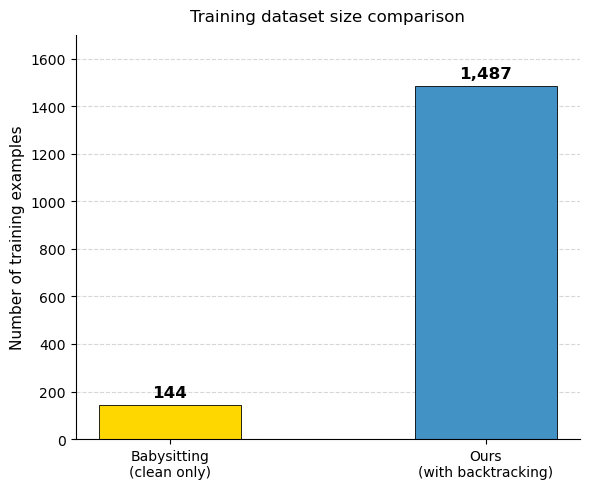

In [83]:
fig, ax = plt.subplots(figsize=(6, 5))

cats   = ['Babysitting\n(clean only)', 'Ours\n(with backtracking)']
vals   = [144, 1487]
colors = [yellow, C_BLUE]

bars = ax.bar(cats, vals, color=colors, edgecolor='black', linewidth=0.6, width=0.45)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 20, f'{int(h):,}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1700)
ax.set_ylabel('Number of training examples', fontsize=11)
ax.set_title('Training dataset size comparison', fontsize=12, fontweight='regular', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('g3_fixed.pdf', dpi=300, bbox_inches='tight')
plt.savefig('g3_fixed.png', dpi=300, bbox_inches='tight')
plt.show()


## Graph 4 — Teacher → Student performance comparison

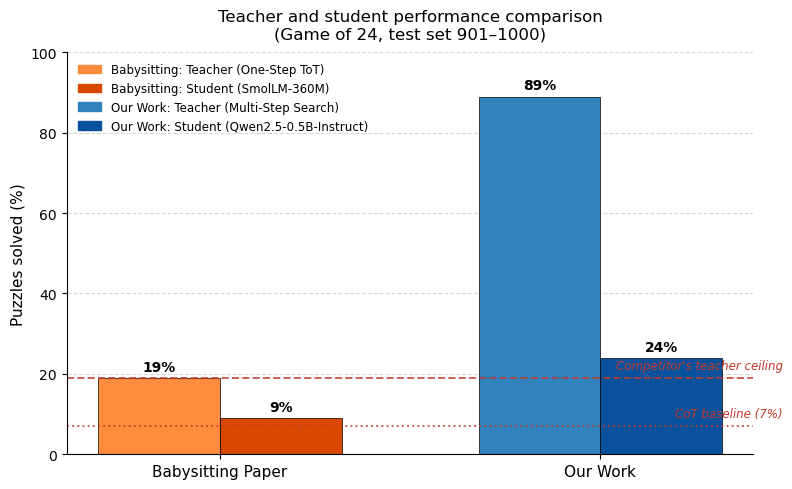

In [5]:
groups = ['Babysitting Paper', 'Our Work']
t_vals = [19, 89]
s_vals = [9,  24]
t_cols = [orange_vivid, blue_medium]
s_cols = [orange_dark,   blue_dark]

x     = np.arange(len(groups))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - width/2, t_vals, width, color=t_cols, edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + width/2, s_vals, width, color=s_cols, edgecolor='black', linewidth=0.5)

for bar_set in [b1, b2]:
    for bar in bar_set:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f'{h}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# competitor ceiling reference line
ax.axhline(y=19, color=C_RED_LINE, linestyle='--', linewidth=1.4, alpha=0.8)
ax.text(1.48, 20.5, "Competitor's teacher ceiling",
        ha='right', va='bottom', fontsize=8.5, color=C_RED_LINE, style='italic')

ax.axhline(y=7, color=C_RED_LINE, linestyle=':', linewidth=1.4, alpha=0.8)
ax.text(1.48, 8.5, 'CoT baseline (7%)',
        ha='right', va='bottom', fontsize=8.5, color=C_RED, style='italic')

ax.set_ylim(0, 100)
ax.set_ylabel('Puzzles solved (%)', fontsize=11)
ax.set_title('Teacher and student performance comparison\n(Game of 24, test set 901–1000)',
             fontsize=12, fontweight='regular', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

legend_handles = [
    mpatches.Patch(color=orange_vivid, label='Babysitting: Teacher (One-Step ToT)'),
    mpatches.Patch(color=orange_dark,   label='Babysitting: Student (SmolLM-360M)'),
    mpatches.Patch(color=blue_medium,       label='Our Work: Teacher (Multi-Step Search)'),
    mpatches.Patch(color=blue_dark,       label='Our Work: Student (Qwen2.5-0.5B-Instruct)'),
]
ax.legend(handles=legend_handles, fontsize=8.5, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('g4_fixed.pdf', dpi=300, bbox_inches='tight')
plt.savefig('g4_fixed.png', dpi=300, bbox_inches='tight')
plt.show()


## Graph 5 — Performance relative to CoT baseline
> CoT is shown as a reference line (not a bar) — same value in both groups so a bar adds noise.

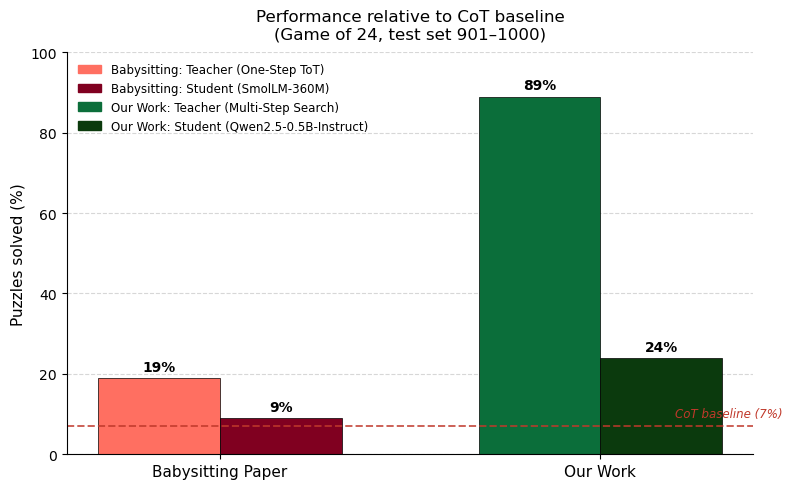

: 

In [ ]:
groups = ['Babysitting Paper', 'Our Work']
t_vals = [19, 89]
s_vals = [9,  24]
t_cols = [C_RED_CORAL, C_GREEN_FOREST]
s_cols = [C_RED_BURGUNDY, C_GREEN_DARK]

x     = np.arange(len(groups))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - width/2, t_vals, width, color=t_cols, edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + width/2, s_vals, width, color=s_cols, edgecolor='black', linewidth=0.5)

for bar_set in [b1, b2]:
    for bar in bar_set:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f'{h}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# CoT as reference line — not a bar
ax.axhline(y=7, color=C_RED_LINE, linestyle='--', linewidth=1.4, alpha=0.8)
ax.text(1.48, 8.5, 'CoT baseline (7%)',
        ha='right', va='bottom', fontsize=8.5, color=C_RED_LINE, style='italic')

ax.set_ylim(0, 100)
ax.set_ylabel('Puzzles solved (%)', fontsize=11)
ax.set_title('Performance relative to CoT baseline\n(Game of 24, test set 901–1000)',
             fontsize=12, fontweight='regular', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

legend_handles = [
    mpatches.Patch(color=C_RED_CORAL, label='Babysitting: Teacher (One-Step ToT)'),
    mpatches.Patch(color=C_RED_BURGUNDY,   label='Babysitting: Student (SmolLM-360M)'),
    mpatches.Patch(color=C_GREEN_FOREST,       label='Our Work: Teacher (Multi-Step Search)'),
    mpatches.Patch(color=C_GREEN_DARK,       label='Our Work: Student (Qwen2.5-0.5B-Instruct)'),
]
ax.legend(handles=legend_handles, fontsize=8.5, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('g5_fixed.pdf', dpi=300, bbox_inches='tight')
plt.savefig('g5_fixed.png', dpi=300, bbox_inches='tight')
plt.show()


Saved: depth_expansion.pdf  /  depth_expansion.png


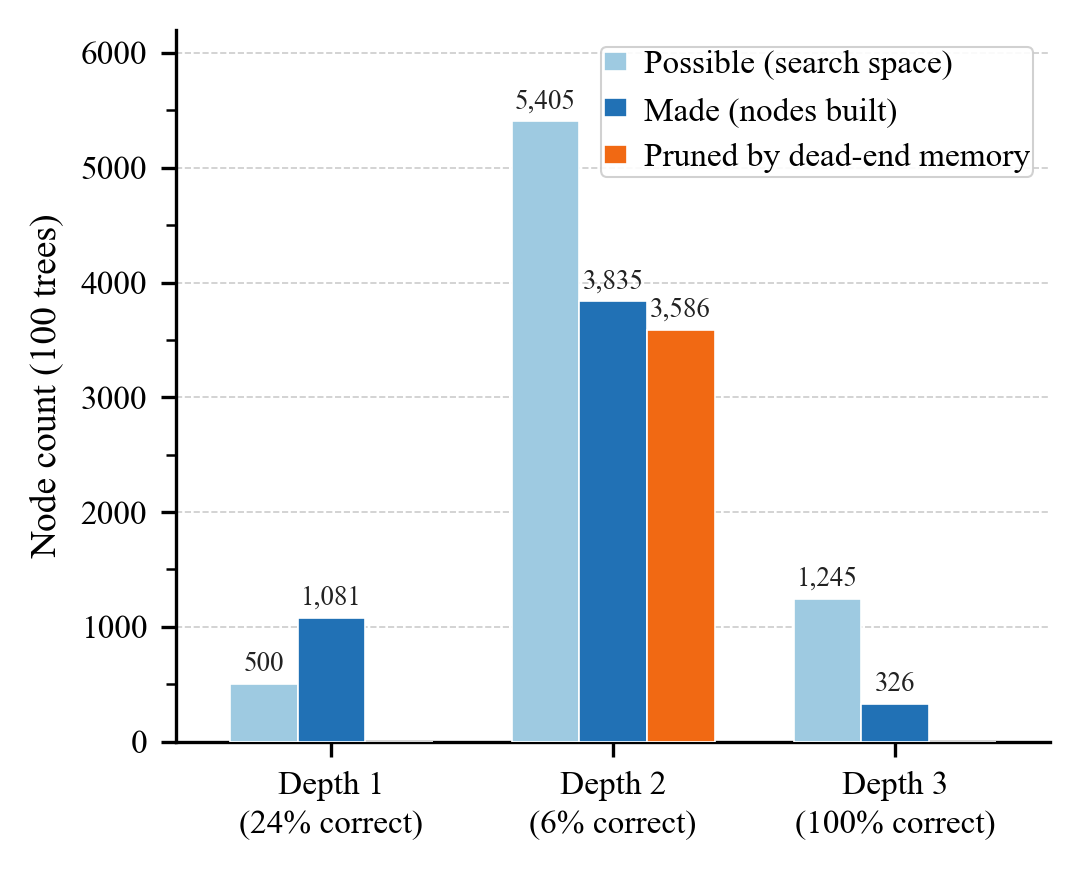

In [4]:
"""
plot_depth_expansion.py
-----------------------
Generates an IEEE-style grouped bar chart for per-depth expansion
and pruning statistics (teacher, test puzzles 901–1000).

Output: depth_expansion.pdf  (vector, for embedding in LaTeX)
        depth_expansion.png  (300 dpi raster, for Word / preview)

Requirements: matplotlib >= 3.5, numpy
"""

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

# ── Data (aggregated over 100 test trees) ────────────────────────────────────
depths       = [1,    2,    3]
possible     = [500,  5405, 1245]
made         = [1081, 3835, 326]
pruned       = [0,    3586, 0]      # zero → bar not drawn
correct_pct  = [24.1, 6.5,  100.0]

# ── IEEE colour palette ───────────────────────────────────────────────────────
# High-chroma but publication-safe; distinguishable in greyscale via value.
C_POSSIBLE = "#9ECAE1"   # muted sky-blue  (lightest → "background / upper bound")
C_MADE     = "#2171B5"   # deep IEEE blue  (darkest → primary measure)
C_PRUNED   = "#F16913"   # vivid amber-orange (mid → secondary measure)

# ── Matplotlib / IEEE RC settings ─────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size":          9,
    "axes.titlesize":     9,
    "axes.labelsize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "legend.fontsize":    8,
    "figure.dpi":         300,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "pdf.fonttype":       42,   # embeds fonts for IEEE submission
    "ps.fonttype":        42,
})

# ── Layout ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.5, 2.8))   # single-column IEEE width

x     = np.arange(len(depths))
w     = 0.24    # individual bar width
offsets = [-w, 0, w]  # Possible, Made, Pruned

# ── Bars ──────────────────────────────────────────────────────────────────────
bars_possible = ax.bar(
    x + offsets[0], possible, width=w,
    color=C_POSSIBLE, edgecolor="white", linewidth=0.4,
    zorder=3, label="Possible (search space)"
)
bars_made = ax.bar(
    x + offsets[1], made, width=w,
    color=C_MADE, edgecolor="white", linewidth=0.4,
    zorder=3, label="Made (nodes built)"
)
bars_pruned = ax.bar(
    x + offsets[2], pruned, width=w,
    color=C_PRUNED, edgecolor="white", linewidth=0.4,
    zorder=3, label="Pruned by dead-end memory"
)

# ── Value labels on bars (only if bar height > 0) ────────────────────────────
def label_bars(bars, values):
    for bar, v in zip(bars, values):
        if v == 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60,
            f"{v:,}",
            ha="center", va="bottom",
            fontsize=6.5, color="#222222",
        )

label_bars(bars_possible, possible)
label_bars(bars_made,     made)
label_bars(bars_pruned,   pruned)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_ylabel("Node count (100 trees)", labelpad=4)
ax.set_ylim(0, 6200)
ax.yaxis.set_major_locator(MultipleLocator(1000))
ax.yaxis.set_minor_locator(MultipleLocator(500))
ax.tick_params(axis="y", which="minor", length=2.5)

# x-axis: two-line labels — depth + correct-path percentage
tick_labels = [
    f"Depth {d}\n({p:.0f}% correct)" for d, p in zip(depths, correct_pct)
]
ax.set_xticks(x)
ax.set_xticklabels(tick_labels, linespacing=1.4)
ax.set_xlim(-0.55, 2.55)

# Subtle horizontal grid (y only, major lines only)
ax.yaxis.grid(True, linestyle="--", linewidth=0.4, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────────────────────
leg = ax.legend(
    loc="upper right", 
    frameon=True, 
    framealpha=0.9, 
    edgecolor="#cccccc", 
    handlelength=0.7,  # <-- Reduced from 1.2
    handleheight=0.5,  # <-- Added to shrink vertical icon size
    handletextpad=0.5, 
    borderpad=0.1,     # <-- Reduced from 0.5 to make the outer box tighter
) 
leg.get_frame().set_linewidth(0.5)


# ── Title (comment out if caption is in LaTeX \caption{}) ────────────────────
# ax.set_title("Per-Depth Expansion and Pruning (test puzzles 901–1000)")

# ── Save ──────────────────────────────────────────────────────────────────────
fig.tight_layout(pad=0.4)
fig.savefig("depth_expansion.pdf", bbox_inches="tight")
fig.savefig("depth_expansion.png", bbox_inches="tight", dpi=300)
print("Saved: depth_expansion.pdf  /  depth_expansion.png")
plt.show()

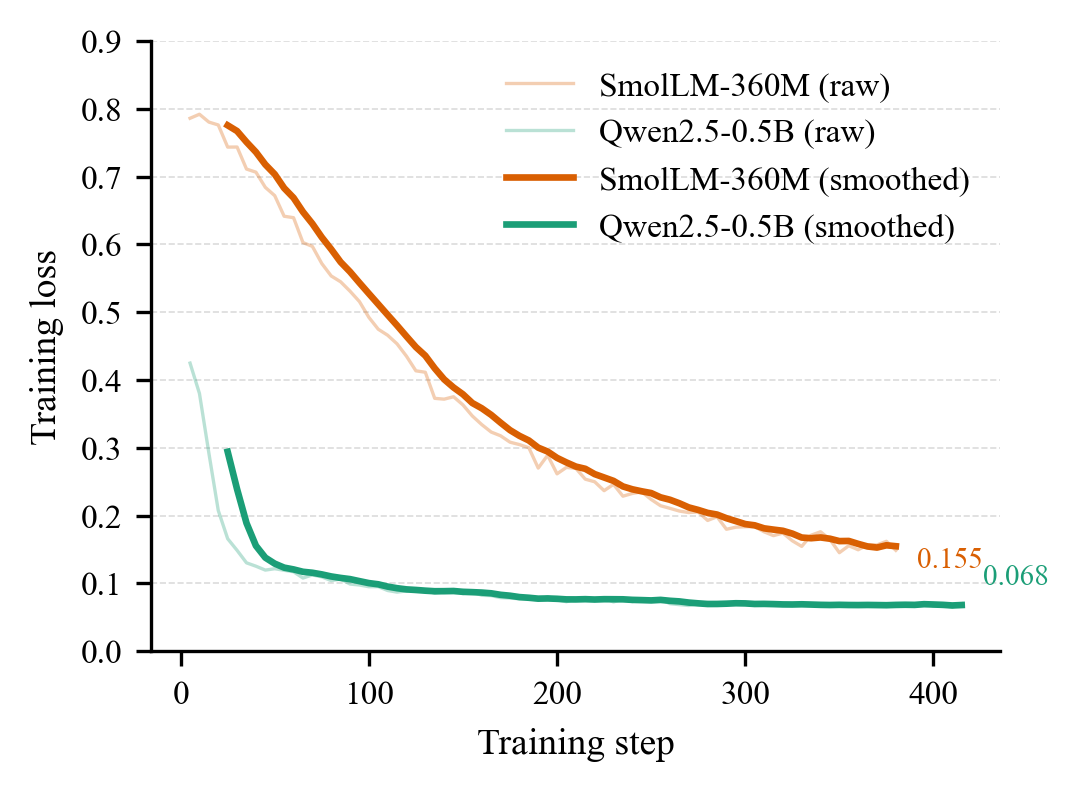

In [2]:
# ────────────────────────────────────────────────────────────────────────────
# Training loss comparison: SmolLM-360M vs Qwen2.5-0.5B-Instruct
# ────────────────────────────────────────────────────────────────────────────

import json
import matplotlib.pyplot as plt
import numpy as np

# ── Load data ───────────────────────────────────────────────────────────────
with open('smollm_training_logs_final.json', 'r') as f:
    smollm_data = json.load(f)

with open('training_logs_qwen05 - try1.json', 'r') as f:
    qwen_data = json.load(f)

# Extract steps and training loss (skip eval entries which lack 'loss')
smollm_steps = [entry['step'] for entry in smollm_data if 'loss' in entry]
smollm_loss = [entry['loss'] for entry in smollm_data if 'loss' in entry]

qwen_steps = [entry['step'] for entry in qwen_data if 'loss' in entry]
qwen_loss = [entry['loss'] for entry in qwen_data if 'loss' in entry]

# Optional: moving average smoothing (window size 5)
def smooth(data, window=5):
    if len(data) < window:
        return data
    weights = np.repeat(1.0, window) / window
    return np.convolve(data, weights, mode='valid')

smollm_smooth = smooth(smollm_loss, window=5)
qwen_smooth   = smooth(qwen_loss,   window=5)

# Align steps for smoothed curves (first (window-1) points lost)
smollm_smooth_steps = smollm_steps[len(smollm_steps)-len(smollm_smooth):]
qwen_smooth_steps   = qwen_steps[len(qwen_steps)-len(qwen_smooth):]

# ── IEEE style plot settings ────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
})

fig, ax = plt.subplots(figsize=(3.5, 2.5))   # single-column width

# Raw training loss (semi‑transparent, thin lines)
ax.plot(smollm_steps, smollm_loss, alpha=0.3, color='#D95F02', linewidth=0.8,
        label='SmolLM-360M (raw)')
ax.plot(qwen_steps, qwen_loss, alpha=0.3, color='#1B9E77', linewidth=0.8,
        label='Qwen2.5-0.5B (raw)')

# Smoothed training loss (thick, solid)
ax.plot(smollm_smooth_steps, smollm_smooth, color='#D95F02', linewidth=1.6,
        label='SmolLM-360M (smoothed)')
ax.plot(qwen_smooth_steps, qwen_smooth, color='#1B9E77', linewidth=1.6,
        label='Qwen2.5-0.5B (smoothed)')

ax.set_xlabel('Training step')
ax.set_ylabel('Training loss')
ax.set_ylim(0, 0.9)   # adjust if needed
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, color='#CCCCCC', alpha=0.7)
ax.set_axisbelow(True)

# Legend without frame
ax.legend(frameon=False, loc='upper right')

# Optional: annotate final smoothed loss values
final_smollm = smollm_smooth[-1]
final_qwen   = qwen_smooth[-1]
ax.annotate(f'{final_smollm:.3f}', xy=(smollm_smooth_steps[-1], final_smollm),
            xytext=(5, -5), textcoords='offset points', fontsize=7, color='#D95F02')
ax.annotate(f'{final_qwen:.3f}', xy=(qwen_smooth_steps[-1], final_qwen),
            xytext=(5, 5), textcoords='offset points', fontsize=7, color='#1B9E77')

plt.tight_layout(pad=0.4)
plt.savefig('training_loss_comparison.pdf', bbox_inches='tight')
plt.savefig('training_loss_comparison.png', bbox_inches='tight', dpi=300)
plt.show()